[IPYKERNEL_LAUNCHER]INFO      Starting ANE2-Calibration-SDR v0.1.0 in America/Bogota...
[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api
[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['FM original'] and nodes: [8]

🚀 Starting Campaign: FM original
  ↳ Node 8 loaded instantly from local cache
[IPYKERNEL_LAUNCHER]INFO      Finished loading data for all campaigns and nodes.
🚀 Starting Plotting Tutorial for Node8
Total signals found: 23


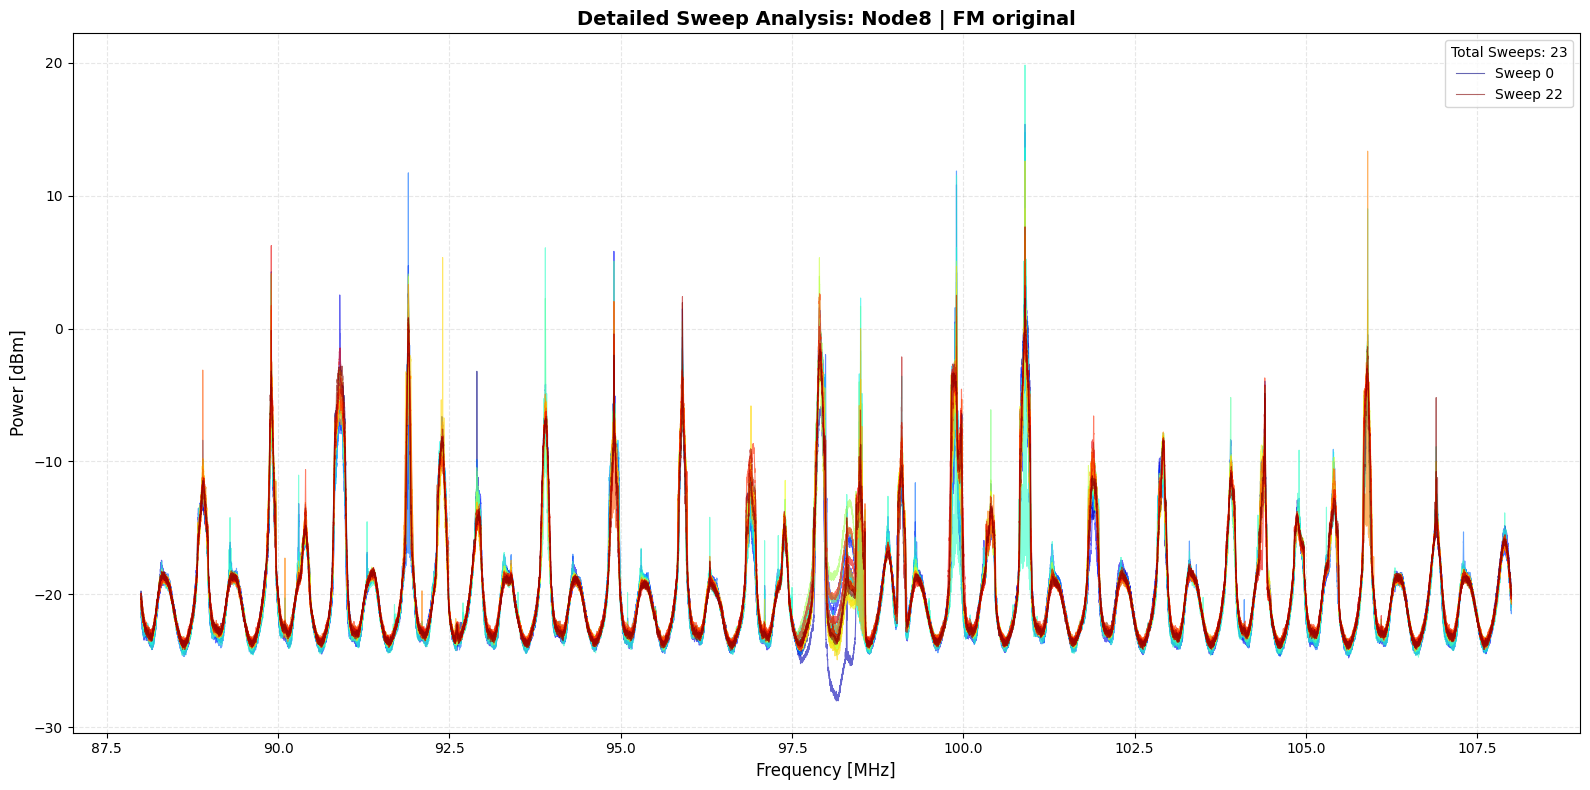

In [ ]:
import sys
sys.path.append('..')

import cfg
import matplotlib.pyplot as plt
import numpy as np
from libs.data_request import DataRequest

log = cfg.set_logger()

# 1. Define your target campaign and the nodes you want to download
camp_ids = {'FM original': 176}
target_nodes = [8]  # We only need node 8 for this tutorial

dr = DataRequest(log=log, base_url=cfg.API_URL)

# 2. Fetch data (this uses the local .cache folder automatically)
df_full = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)

# 3. Drill down into the nested dictionary
campaign_label = "FM original"
node_key = "Node8"
df_node = df_full[campaign_label][node_key]

# Initialize the plot
plt.figure(figsize=(16, 8))

# 4. COLOR MANAGEMENT
# We create a 'rainbow' or 'viridis' effect so every line has a unique color
num_signals = len(df_node)
colors = plt.cm.jet(np.linspace(0, 1, num_signals))

print(f"🚀 Starting Plotting Tutorial for {node_key}")
print(f"Total signals found: {num_signals}")

# 5. THE EXPLICIT LOOP
# We use enumerate to get both the index (for the color) and the row data
for i, (idx, row) in enumerate(df_node.iterrows()):
    
    # A. Convert the 'pxx' string/list into a clean numpy array
    # In your class, pxx might come as a list or a string depending on the API state
    pxx = np.array(row['pxx'])
    
    # B. Reconstruct the Frequency Axis
    # The API gives us Start and End. We need to create a point for every value in pxx.
    f_start = row['start_freq_hz'] / 1e6  # Convert to MHz
    f_end = row['end_freq_hz'] / 1e6      # Convert to MHz
    freq_axis = np.linspace(f_start, f_end, len(pxx))
    
    # C. Plot the individual line
    # We only label the first and last to keep the legend small
    label = f"Sweep {i}" if i == 0 or i == num_signals - 1 else None
    plt.plot(freq_axis, pxx, color=colors[i], alpha=0.6, linewidth=0.8, label=label)

# 6. BEAUTIFICATION
plt.title(f"Detailed Sweep Analysis: {node_key} | {campaign_label}", fontsize=14, fontweight='bold')
plt.xlabel("Frequency [MHz]", fontsize=12)
plt.ylabel("Power [dBm]", fontsize=12)

# Add context to the legend
plt.legend(title=f"Total Sweeps: {num_signals}", loc='upper right')

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()